In [ ]:
options(future.globals.maxSize = 100000000 * 1024^2)

# set random seed for reproducibility
set.seed(12345)

# ========================= Libraries ===================================


## We load the required packages
library(dplyr)
library(Seurat)
library(readr)
library(readr)
# single-cell analysis package
# plotting and data science packages
# library(tidyverse)
library(cowplot)
library(patchwork)
library(ggplot2)
# co-expression network analysis packages:
library(igraph)
library(harmony)
library(dittoSeq)
library(RColorBrewer)

library(org.Hs.eg.db)
require(tidyverse)
library(clusterProfiler)
library(WGCNA)
library(hdWGCNA)
library(scCustomize)
library(harmony)


library(SCopeLoomR)
library(dreamlet)
library(SingleCellExperiment)
library(scater)
# library(UCell)
# library(Nebulosa)

library(SingleCellExperiment)
library(scuttle)
library(Seurat)
library(doParallel)
'%notin%' <- Negate('%in%')

# plotting
library(ggplot2)
library(dplyr)
library(RColorBrewer)
library(cowplot)
library(ggtree)
library(aplot)
library(circlize)
library(ComplexHeatmap)

# meta
library(tidyr)
library(muscat)
library(broom)
library(tidyverse)
library(metafor) 

input_rds <- args[1]
group_by <- args[2]
only_microglia <- as.logical(args[3])
n_of_aggregated <- as.numeric(args[4]) # 25
n_of_aggregated_text <- args[4]
threads <- as.numeric(args[5])
output_pdf <- args[6]

workdir <- "7.WGCNA/"
source('utils.R')
dir.create(workdir)
registerDoParallel(cores=threads)
colors <- brewer.pal(n = 9, name = 'Set3')
colors[2] <- colors[8]
colors[8] <- "azure3"
colors_rb <- rev(brewer.pal(n = 6, name = 'RdGy'))


# Read Metacell object

In [2]:
WGCNA_dir = '/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/result/Cortex/7.WGCNA/'
SCENIC_dir = '/sc/arion/projects/CommonMind/kyriad02/ICH_Stroke/result/Cortex/8.SCENIC/'
input_rds <-  paste0(WGCNA_dir,'2024_03_28_Myeloid_Metacells_Subclass_ADAM.rds.ztsd')
input_loom <-  paste0(SCENIC_dir,'Myeloid/2024_04_01_Myeloid_Metacells_ExtendedGenes.loom')

Metacells <- readCRDS(input_rds)
Metacells$TwoClusters <-  as.vector(Metacells$Clusters)
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_1","MTC_2","MTC_3")] <- "MTC_123"
Metacells$TwoClusters[Metacells$Clusters %in% c("MTC_4","MTC_5","MTC_6")]<- "MTC_456"


# Prepare Single Cell Experiment Object

In [3]:
library(crumblr)
mat <- as.matrix(Metacells@assays$RNA@counts)
dim(mat)
sce <- SingleCellExperiment(
  assays = list(counts = mat),
  colData = Metacells@meta.data
)

Warning message:
"no DISPLAY variable so Tk is not available"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 3.8 GiB"


[1] 17500 28858

# Aggregate to Pseudobulk

In [4]:

group_by_cl <- "Clusters"
library(dreamlet)
pbObj_subtype <- aggregateToPseudoBulk(sce,
    assay = "counts",
    cluster_id = group_by_cl,
    sample_id = "Donor",
    BPPARAM = SnowParam(5, progressbar=TRUE))


Warning message in .check_arg_assay(x, assay, checkValues):
"Assay 'counts' stores continuous values instead of counts.
	Make sure this is the intended assay.
	This dataset contains assays: counts"


# Run Crumblr - Variance partition

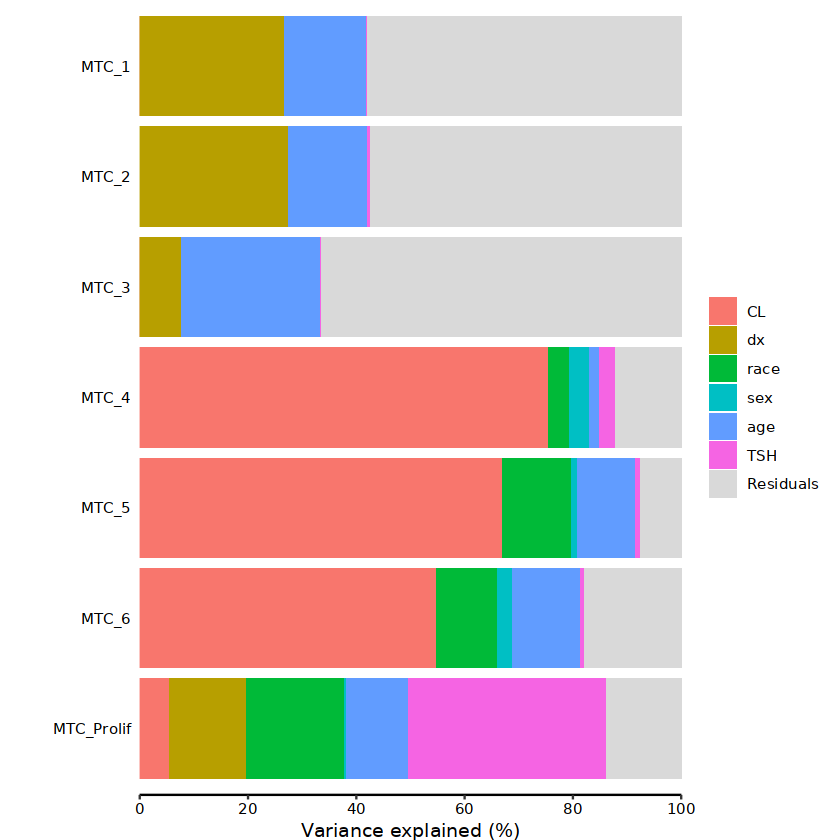

In [6]:
cobj = crumblr(cellCounts(pbObj_subtype))
# Partition variance into components for Subject (i.e. ind)
#   and stimulation status, and residual variation
vp = fitExtractVarPartModel( cobj, ~ (1|race) +(1|sex)+(1|CL)+(1|dx)+age+TSH, colData(pbObj_subtype))
# Plot variance fractions
plotPercentBars(vp)

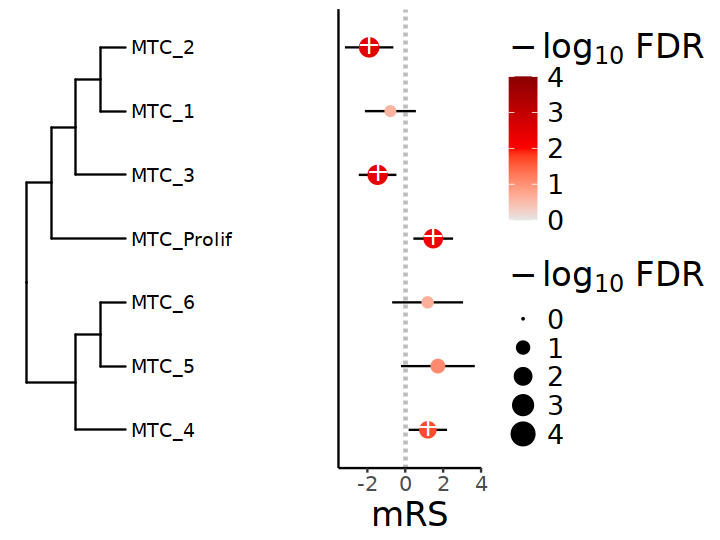

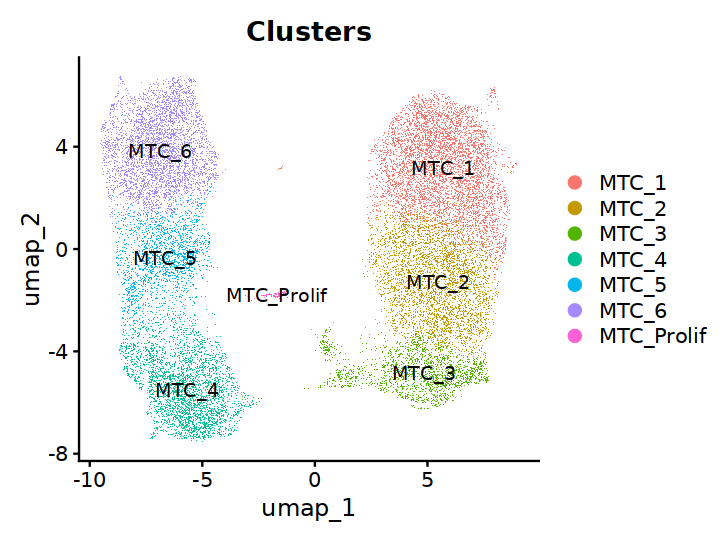

In [7]:
form = ~mRS_binned+(1|sex)+dx+age+CL +0
L = makeContrastsDream(form, colData(pbObj_subtype),
                       contrasts=c(mRS_contrast="mRS_binnedB -mRS_binnedG"))
fit = dream(cobj, form, colData(pbObj_subtype), L=L)
fit = eBayes(fit)                                                    
res.mRS = topTable(fit, coef="mRS_contrast", 
                   number=Inf, 
                   sort.by="none")
res.mRS$assay <- rownames(res.mRS )
res.age = dh_meta_analysis(list(res.mRS))
hc = buildClusterTreeFromPB(pbObj_subtype)
fig.tree = dh_plotTree(ape::as.phylo(hc),
                       xmax.scale=2.5) + 
                theme(legend.position="bottom",text = element_text(size = 30))+
theme(text=element_text(size=15))
fig.es1<- dh_plotCoef(res.age, coef='mRS', fig.tree, ylab='mRS')
options(repr.plot.width=6, repr.plot.height=4.5)
fig.es1 %>% insert_left(fig.tree, width=2) 
p1 <- DimPlot(Metacells,group.by = 'Clusters',label=T,raster=T)
p1

In [9]:
low="grey90"
mid = "red"
high="darkred"
xmax.scale =3.5

In [11]:
res = treeTest( fit, cobj, hc, coef="mRS_contrast")

# Plot hierarchy and testing results
tree  = res
fig = ggtree(tree, branch.length = "none") + 
        geom_tiplab(color = "black", size=4, hjust=0, offset=.2) +
        theme(legend.position="top left", plot.title = element_text(hjust = 0.5))
# get default max value of x-axis
xmax = layer_scales(fig)$x$range$range[2]

png 
  2

png 
  2

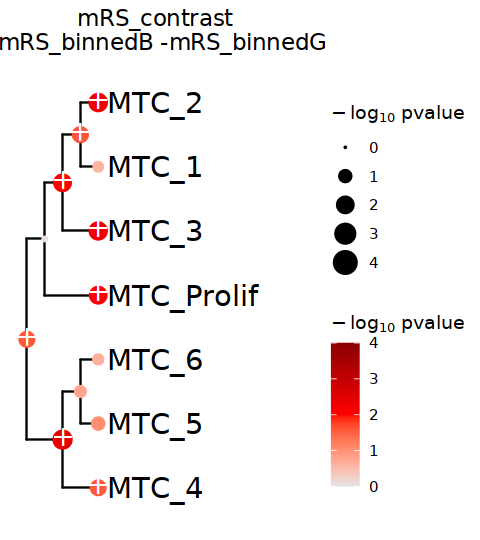

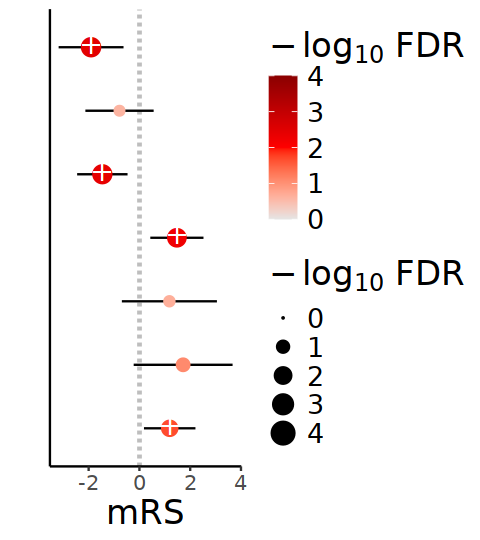

In [13]:
p <- ggtree(res, branch.length = "none") + 
    geom_tiplab(color = "black", size=6, hjust=0, offset=.5) +
    geom_point2(aes(label = node, color=pmin(4,-log10(pvalue)), size=pmin(5,-log10(pvalue)))) + 
    scale_color_gradient2(name = bquote(-log[10]~pvalue), limits=c(0,4), low=low, mid=mid, high=high, midpoint=-log10(0.01)) +
    scale_size_area(name = bquote(-log[10]~pvalue), limits=c(0,4)) +
    geom_text2(aes(label = '+', subset=pvalue < 0.05), color = "white", size=6, vjust=.3, hjust=.5) +
    theme(legend.position="right", plot.title = element_text(hjust = 0.5))+ 
    xlim(0, xmax*xmax.scale)+ggtitle("mRS_contrast \n mRS_binnedB -mRS_binnedG")
pdf('Figure2_C1.pdf',width = 6,height=4.5)
p
dev.off()

pdf('Figure2_C2.pdf',width = 4,height=4.5)
options(repr.plot.width=4, repr.plot.height=4.5)
fig.es1
dev.off()

p
fig.es1


In [14]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 21.04

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
[1] C

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
 [1] grid      parallel  stats4    stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] crumblr_0.99.6              metafor_4.2-0              
 [3] numDeriv_2016.8-1.1         metadat_1.2-0              
 [5] Matrix_1.5-4.1              broom_1.0.5                
 [7] muscat_1.14.0               ComplexHeatmap_2.16.0      
 [9] circlize_0.4.15             aplot_0.1.10               
[11] ggtree_3.8.0                doParallel_1.0.17          
[13] iterators_1.0.14            foreach_1.5.2              
[15] scater_1.28.0               scuttle_1.10.1             
[17] SingleCellExperiment_1.22.0 Su